# K Nearest Neighbors Implementartion using MapReduce in Spark

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, IntegerType, DoubleType, ArrayType, StringType
)
import pandas as pd
import math, time, json
from collections import Counter
import numpy as np
import json
from functools import partial

# on Databricks, use this: 
spark = SparkSession.builder \
    .appName("MR_KNN_DataFrame_Paper") \
    .getOrCreate()

# otherwise, use this: 
# spark = SparkSession.builder \
#     spark = SparkSession.builder \
#     .appName("MR_KNN_DataFrame_Paper") \
#     .master("local[*]") \
#     .getOrCreate()
# spark.sparkContext.setLogLevel("ERROR")


print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/02 21:07:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


# DataFrame implementation

## Load Dataset

In [2]:
# Load Poker Hand dataset
COL_NAMES    = ["S1","C1","S2","C2","S3","C3","S4","C4","S5","C5","label"]
FEATURE_COLS = ["S1","C1","S2","C2","S3","C3","S4","C4","S5","C5"]

def load_dataset(path):
    df = spark.read.csv(path, header=False, inferSchema=True)
    for i, name in enumerate(COL_NAMES):
        df = df.withColumnRenamed(f"_c{i}", name)
    return df

train_full = load_dataset("Dataset/poker+hand/poker-hand-training-true.data")
test_df_full = load_dataset("Dataset/poker+hand/poker-hand-testing.data")

print(f"Training rows (full): {train_full.count()}")
print(f"Test rows:            {test_df_full.count()}")

Training rows (full): 25010
Test rows:            1000000


In [3]:
# Parameters & subsampling
K        = 5
FRACTION = 0.1
N_PARTS  = 16    # number of map tasks

train_df = train_full.sample(withReplacement=False, fraction=FRACTION, seed=42)
test_df  = test_df_full.limit(5000)

# Pre-compute test matrix on driver once 
test_collected = test_df.collect()

test_matrix = np.array([
    [row[f] for f in FEATURE_COLS] for row in test_collected
])  

print(f"Test size:        {len(test_collected)}")
print(f"Test matrix shape: {test_matrix.shape}")

Test size:        5000
Test matrix shape: (5000, 10)


## Map phase

In [4]:
# Map phase
#
# We repartition the training DataFrame into N_PARTS partitions,
# then use applyInPandas (grouped map) to apply one map function
# per partition, each partition is TR_j, one map task.
#
#   - Input:  a pandas DataFrame chunk (= TR_j)
#   - Output: a pandas DataFrame with one row per (test_point, neighbour)
#             encoding the CD_j matrix from the paper
#
# CD_j entry: (label, dist) as per paper's <Class(neigh_n), Dist(neigh_n)>


# Output schema for the pandas UDF:
# For each (partition, test_index) we store the k neighbours as a
# JSON string so we can pass the full CD_j matrix through a DataFrame.
map_output_schema = StructType([
    StructField("partition_id", IntegerType(), False),
    StructField("test_index",   IntegerType(), False),
    # JSON-encoded list of k [label, dist] pairs — the CD_j row
    StructField("neighbors",    StringType(),  False),
])


def map_partition(train_chunk: pd.DataFrame,
                  test_mat,
                  feature_cols,
                  k) -> pd.DataFrame:
    """
    Algorithm 1 (Map function)

    Receives TR_j as a pandas DataFrame (one Spark partition).
    Computes all pairwise distances between test points and TR_j
    using a fully vectorised numpy matrix operation.

    For each test point, stores the k nearest neighbours as
    [label, dist] pairs sorted ascending by distance — matching
    the paper's CD_j matrix definition where entries are
    <Class(neigh_n), Dist(neigh_n)> ordered by distance.

    Require: TS, k
    1. TR_j is this partition (train_chunk)
    2. for i = 0 to size(TS):
    3.     compute k-NN(x_test,i, TR_j, k)
    4-6.   CD_j(i,n) = <Class(neigh_n), Dist(neigh_n)>
    8. key = partition_id
    9. EMIT(<key, CD_j>)
    """

    partition_id   = train_chunk["partition_id"].iloc[0]
    train_features = train_chunk[feature_cols].values        # (n_train_j, 10)
    train_labels   = train_chunk["label"].values.astype(int) # (n_train_j,)

    # Fully vectorised distance matrix
    # Uses the identity: ||a-b||² = ||a||² + ||b||² - 2(a·b)
    # Computes ALL pairwise distances in one matrix operation.
    # dist_mat[i,j] = distance from test point i to train point j
    #
    # Shapes:
    #   test_sq:  (n_test, 1)      squared norms of test points
    #   train_sq: (1, n_train_j)   squared norms of train points
    #   dot:      (n_test, n_train_j)  dot products
    #   dist_mat: (n_test, n_train_j)  all pairwise distances
    test_sq  = (test_mat ** 2).sum(axis=1, keepdims=True)
    train_sq = (train_features ** 2).sum(axis=1, keepdims=True).T
    dot      = test_mat @ train_features.T
    dist_mat = np.sqrt(np.maximum(test_sq + train_sq - 2 * dot, 0))

    top_k_idx = np.argpartition(dist_mat, k, axis=1)[:, :k]  # (n_test, k)

    output_rows = []
    for i in range(len(test_mat)):
        idx   = top_k_idx[i]
        # Sort the k candidates by distance
        top_k = sorted(
            [[int(train_labels[j]), float(dist_mat[i, j])] for j in idx],
            key=lambda x: x[1]   
        )
        output_rows.append({
            "partition_id": partition_id,
            "test_index":   i,
            "neighbors":    json.dumps(top_k) 
        })

    return pd.DataFrame(output_rows)


## Reduce phase

In [5]:
# Reduce functions (Algorithms 2 & 3)

def reduce_cd(CD_reducer, CD_j, k):
    """
    Algorithm 2 (Reduce operation) — Maillo et al. 2015.

    Merges CD_j (from one map task) into CD_reducer by comparing
    distances and keeping the k globally nearest neighbours per
    test point. Both lists are sorted ascending by distance.

    Complexity: O(k) per test point — merge of two sorted k-lists.

    Require: size(TS), k, CD_j
      size(TS) implicit as len(CD_reducer)
      k passed explicitly
      CD_j is the incoming map output matrix

    Entries are (label, dist) — we compare on dist (index 1).
    """
    t = len(CD_reducer)
    for i in range(t):
        merged = []
        a, b   = 0, 0
        while len(merged) < k:
            # Compare distances (index 1) of current candidates
            dist_r = CD_reducer[i][a][1] if a < k else float('inf')
            dist_j = CD_j[i][b][1]       if b < k else float('inf')
            if dist_r <= dist_j:
                merged.append(CD_reducer[i][a]); a += 1
            else:
                merged.append(CD_j[i][b]);       b += 1
        CD_reducer[i] = merged
    return CD_reducer

def majority_vote(neighbors):
    """
    Algorithm 3 cleanup: majority vote over k neighbours' classes.
    neighbors = [[label, dist], ...] — vote on label (index 0).
    """
    classes = [label for (label, _) in neighbors]
    return Counter(classes).most_common(1)[0][0]

## MR-KNN function 

In [6]:
def mr_knn_dataframe(train_df, test_collected, test_matrix,
                     feature_cols, k, n_partitions):
    """
    MR-KNN faithful to Maillo et al. 2015 using Spark DataFrames.

    Map phase:
        applyInPandas applies map_partition once per partition —
        each partition is TR_j, one map task. Extra parameters
        (test_matrix, feature_cols, k) passed via functools.partial.

    Reduce phase:
        Collects map outputs to driver, merges each CD_j into
        CD_reducer using Algorithm 2 (single reducer design).

    Cleanup:
        Majority vote per test point (Algorithm 3).

    Returns predictions and timing breakdown (map time, reduce time).
    """
    n_test = len(test_collected)

    # MAP PHASE
    t_map_start = time.time()

    # Repartition TR into n_partitions disjoint subsets (TR_1...TR_m).
    # spark_partition_id() assigns each row its partition number 
    train_part = (
        train_df
        .select(feature_cols + ["label"])   # column pruning
        .repartition(n_partitions)
        .withColumn("partition_id", F.spark_partition_id())
    )

    # Pre-fill test_mat, feature_cols, k into map_partition via partial.
    map_fn = partial(map_partition,
                     test_mat     = test_matrix,
                     feature_cols = feature_cols,
                     k            = k)

    
    map_output_df = (
        train_part
        .groupBy("partition_id")
        .applyInPandas(map_fn, schema=map_output_schema)
    )

   
    map_rows = map_output_df.orderBy("partition_id", "test_index").collect()
    t_map    = time.time() - t_map_start

    # REDUCE PHASE — Setup 
    # Initialise CD_reducer: t rows x k columns, all dist = +inf.
    t_red_start = time.time()
    CD_reducer  = [[(-1, float('inf'))] * k for _ in range(n_test)]

    # REDUCE PHASE — Reduce (Algorithm 2) 
    # Iterate through map_rows, reconstructing one CD_j at a time.
    # When we detect a new partition_id, the previous CD_j is complete
    # so we merge it into CD_reducer before moving on.
    current_partition = None
    CD_j              = [None] * n_test

    for row in map_rows:
        pid       = row["partition_id"]
        test_idx  = row["test_index"]
        neighbors = json.loads(row["neighbors"])  

        # New partition detected — merge completed CD_j into CD_reducer
        if current_partition is not None and pid != current_partition:
            CD_reducer = reduce_cd(CD_reducer, CD_j, k)
            CD_j       = [None] * n_test

        current_partition  = pid
        CD_j[test_idx]     = neighbors

    # Merge the final partition
    if current_partition is not None:
        CD_reducer = reduce_cd(CD_reducer, CD_j, k)

    # REDUCE PHASE — Cleanup (Algorithm 3) 
    # CD_reducer now holds the definitive global top-k for every
    # test point. Majority vote gives the predicted class.
    results = [
        (i, majority_vote(CD_reducer[i]), int(test_collected[i]["label"]))
        for i in range(n_test)
    ]
    t_red = time.time() - t_red_start

    return results, t_map, t_red

## Sequential KNN for DF

In [7]:
def sequential_knn(train_matrix, train_labels, test_collected, test_matrix, k):

    start = time.time()

    # Fully vectorised distance matrix but computed all at once on a single machine, no partitioning
    test_sq  = (test_matrix ** 2).sum(axis=1, keepdims=True)
    train_sq = (train_matrix ** 2).sum(axis=1, keepdims=True).T
    dot      = test_matrix @ train_matrix.T
    dist_mat = np.sqrt(np.maximum(test_sq + train_sq - 2 * dot, 0))

    # For each test point, get k nearest and majority vote
    top_k_idx = np.argpartition(dist_mat, k, axis=1)[:, :k]
    correct   = 0
    for i in range(len(test_collected)):
        idx        = top_k_idx[i]
        top_k      = sorted([(int(train_labels[j]), float(dist_mat[i,j]))
                              for j in idx], key=lambda x: x[1])
        predicted  = Counter(label for label, _ in top_k).most_common(1)[0][0]
        actual     = int(test_collected[i]["label"])
        correct   += (predicted == actual)

    elapsed  = time.time() - start
    accuracy = correct / len(test_collected)
    return accuracy, elapsed

## Trial run 

In [8]:
# sequential knn 
train_collected_full = train_full.select(FEATURE_COLS + ["label"]).collect()
train_matrix_full    = np.array([[row[f] for f in FEATURE_COLS] for row in train_collected_full])
train_labels_full    = np.array([int(row["label"]) for row in train_collected_full])

seq_accuracy, seq_time = sequential_knn(
    train_matrix   = train_matrix_full,
    train_labels   = train_labels_full,
    test_collected = test_collected,
    test_matrix    = test_matrix,
    k              = K
)


# mr knn 
results, t_map, t_red = mr_knn_dataframe(
    train_df       = train_full,
    test_collected = test_collected,
    test_matrix    = test_matrix,
    feature_cols   = FEATURE_COLS,
    k              = K,
    n_partitions   = N_PARTS
)

correct  = sum(1 for (_, p, a) in results if p == a)
accuracy = correct / len(results)

# print results

print(f"Train size  : {train_full.count()}")
print(f"Test size   : {len(results)}")
print(f"K           : {K}")
print(f"Partitions  : {N_PARTS}")

print("\nSEQUENTIAL KNN")
print(f"Sequential Accuracy    : {seq_accuracy:.4f}")
print(f"Sequential time: {seq_time:.2f}s")

print("\nMR KNN")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Map time    : {t_map:.2f}s")
print(f"Reduce time : {t_red:.2f}s")
print(f"Total time  : {t_map + t_red:.2f}s")

print(f"Accuracy difference: {seq_accuracy - accuracy:.5f}")
print(f"Speedup: {seq_time / (t_map + t_red):.4f}x")

/users/eleves-a/2022/kenza.chaabouni/.local/lib/python3.13/site-packages/pyspark/sql/pandas/group_ops.py:295: UserWarning: Cannot infer the eval type from type hints: functools.partial(<function map_partition at 0x7fb9d4d891c0>, test_mat=array([[ 1,  1,  1, ...,  3,  1, 12],
       [ 3, 12,  3, ...,  5,  2,  5],
       [ 1,  9,  4, ...,  2,  3,  9],
       ...,
       [ 4, 12,  1, ...,  7,  4,  6],
       [ 4,  8,  3, ..., 12,  3,  4],
       [ 1,  7,  4, ...,  2,  3,  3]], shape=(5000, 10)), feature_cols=['S1', 'C1', 'S2', 'C2', 'S3', 'C3', 'S4', 'C4', 'S5', 'C5'], k=5) is not a module, class, method, or function.
  warnings.warn(f"Cannot infer the eval type from type hints: {e}", UserWarning)


Train size  : 25010
Test size   : 5000
K           : 5
Partitions  : 16

SEQUENTIAL KNN
Sequential Accuracy    : 0.5530
Sequential time: 1.85s

MR KNN
Accuracy    : 0.5514
Map time    : 7.29s
Reduce time : 0.50s
Total time  : 7.79s
Accuracy difference: 0.00160
Speedup: 0.2376x


## Experimental Analysis

### 5-fold cv - Speedup

In [9]:
# 5-Fold Cross Validation

# Combine train and test into one full DataFrame
# Add a fold_id column using row index % 5
full_df = train_df.union(test_df) 

# Add row index to assign folds deterministically
from pyspark.sql.window import Window
full_df = full_df.withColumn(
    "fold_id",
    F.monotonically_increasing_id() % 5
)
full_df.cache()

K_VALUES = [1, 3, 5, 7]
M_VALUES = [16, 32, 64, 128, 256]
N_FOLDS  = 5

all_results = []

# 5-Fold Cross Validation loop 
for fold in range(N_FOLDS):
    print(f"\n=== Fold {fold + 1} / {N_FOLDS} ===")

    fold_train_df = full_df.filter(F.col("fold_id") != fold).drop("fold_id")
    fold_test_df  = full_df.filter(F.col("fold_id") == fold).drop("fold_id")

    fold_train_df.cache()
    fold_test_df.cache()

    fold_test_collected = fold_test_df.collect()
    fold_test_matrix    = np.array([
        [row[f] for f in FEATURE_COLS] for row in fold_test_collected
    ])

    fold_train_collected = fold_train_df.collect()
    fold_train_matrix    = np.array([
        [row[f] for f in FEATURE_COLS] for row in fold_train_collected
    ])
    fold_train_labels    = np.array([
        int(row["label"]) for row in fold_train_collected
    ])

    for k_val in K_VALUES:
        print(f"  k={k_val}")

        # Sequential knn
        seq_acc, seq_time = sequential_knn(
            train_matrix   = fold_train_matrix,
            train_labels   = fold_train_labels,
            test_collected = fold_test_collected,
            test_matrix    = fold_test_matrix,
            k              = k_val
        )
        all_results.append({
            "fold"       : fold + 1,
            "k"          : k_val,
            "m"          : 1,
            "type"       : "sequential",
            "accuracy"   : round(seq_acc, 4),
            "map_time"   : None,
            "reduce_time": None,
            "global_time": round(seq_time, 3),
            "speedup"    : 1.0
        })
        print(f"    sequential → time={seq_time:.2f}s | acc={seq_acc:.4f}")

        # MR-KNN 
        for m in M_VALUES:
            print(f"    m={m}")

            results, t_map, t_red = mr_knn_dataframe(
                train_df       = fold_train_df,
                test_collected = fold_test_collected,
                test_matrix    = fold_test_matrix,
                feature_cols   = FEATURE_COLS,
                k              = k_val,
                n_partitions   = m
            )

            acc = sum(1 for (_, p, a) in results if p == a) / len(results)
            all_results.append({
                "fold"       : fold + 1,
                "k"          : k_val,
                "m"          : m,
                "type"       : "MR-kNN",
                "accuracy"   : round(acc, 4),
                "map_time"   : round(t_map, 3),
                "reduce_time": round(t_red, 3),
                "global_time": round(t_map + t_red, 3),
                "speedup"    : round(seq_time / (t_map + t_red), 3)
            })
            print(f"      → MapT={t_map:.2f}s | RedT={t_red:.2f}s | "
                  f"Acc={acc:.4f} | Speedup={seq_time/(t_map+t_red):.3f}x")

    fold_train_df.unpersist()
    fold_test_df.unpersist()

full_df.unpersist()

# Average results over 5 folds
results_df = pd.DataFrame(all_results)

avg_df = (
    results_df
    .groupby(["k", "m", "type"])
    .agg(
        accuracy    =("accuracy",    "mean"),
        map_time    =("map_time",    "mean"),
        reduce_time =("reduce_time", "mean"),
        global_time =("global_time", "mean"),
        speedup     =("speedup",     "mean")
    )
    .round(4)
    .reset_index()
)

print("\n=== Results Averaged over 5 Folds ===")
print(avg_df.to_string(index=False))

avg_df.to_csv("cv_results.csv",index=False)


=== Fold 1 / 5 ===


  k=1
    sequential → time=0.15s | acc=0.4747
    m=16


/users/eleves-a/2022/kenza.chaabouni/.local/lib/python3.13/site-packages/pyspark/sql/pandas/group_ops.py:295: UserWarning: Cannot infer the eval type from type hints: functools.partial(<function map_partition at 0x7fb9d4d891c0>, test_mat=array([[ 2,  1,  2, ...,  4,  2,  5],
       [ 1,  2,  4, ..., 11,  4, 13],
       [ 2,  1,  3, ...,  2,  3,  1],
       ...,
       [ 2,  3,  4, ...,  3,  1,  9],
       [ 1, 13,  4, ..., 11,  3,  1],
       [ 4,  8,  3, ..., 12,  3,  4]], shape=(1502, 10)), feature_cols=['S1', 'C1', 'S2', 'C2', 'S3', 'C3', 'S4', 'C4', 'S5', 'C5'], k=1) is not a module, class, method, or function.
  warnings.warn(f"Cannot infer the eval type from type hints: {e}", UserWarning)


      → MapT=1.07s | RedT=0.11s | Acc=0.4787 | Speedup=0.125x
    m=32
      → MapT=1.38s | RedT=0.12s | Acc=0.4754 | Speedup=0.098x
    m=64


      → MapT=2.10s | RedT=0.24s | Acc=0.4767 | Speedup=0.063x
    m=128


...

      → MapT=1.15s | RedT=0.14s | Acc=0.5556 | Speedup=0.109x
    m=32


      → MapT=1.85s | RedT=0.34s | Acc=0.5536 | Speedup=0.065x
    m=64


      → MapT=3.03s | RedT=0.76s | Acc=0.5556 | Speedup=0.037x
    m=128


      → MapT=5.54s | RedT=1.35s | Acc=0.5490 | Speedup=0.021x
    m=256


      → MapT=10.71s | RedT=2.68s | Acc=0.5490 | Speedup=0.011x

=== Results Averaged over 5 Folds ===
 k   m       type  accuracy  map_time  reduce_time  global_time  speedup
 1   1 sequential    0.4903       NaN          NaN       0.1426   1.0000
 1  16     MR-kNN    0.4934    0.8718       0.0724       0.9444   0.1530
 1  32     MR-kNN    0.4917    1.2904       0.1194       1.4104   0.1012
 1  64     MR-kNN    0.4899    1.9836       0.2626       2.2464   0.0636
 1 128     MR-kNN    0.4938    3.3850       0.5496       3.9348   0.0362
 1 256     MR-kNN    0.4932    6.2576       0.9354       7.1930   0.0198
 3   1 sequential    0.5222       NaN          NaN       0.1386   1.0000
 3  16     MR-kNN    0.5295    0.9768       0.1094       1.0862   0.1280
 3  32     MR-kNN    0.5223    1.4808       0.2054       1.6860   0.0824
 3  64     MR-kNN    0.5223    2.3768       0.4078       2.7846   0.0498
 3 128     MR-kNN    0.5242    4.1712       0.7338       4.9052   0.0286
 3 256     MR-kNN    0

### Varying training fraction and k, with constant # mappers (16)

In [10]:
FRACTIONS  = [0.1, 0.25, 0.5, 0.75, 1.0]
K_VALUES   = [1, 3, 5, 7]
records    = []
total_runs = len(FRACTIONS) * len(K_VALUES)
run        = 0

for k_val in K_VALUES:
    for frac in FRACTIONS:
        run += 1
        train_sample = train_full.sample(False, frac, seed=42)
        n_train      = train_sample.count()
        print(f"[{run}/{total_runs}] k={k_val} | frac={frac} | n_train={n_train}...")

        results, t_map, t_red = mr_knn_dataframe(
            train_df       = train_sample,
            test_collected = test_collected,
            test_matrix    = test_matrix,
            feature_cols   = FEATURE_COLS,
            k              = k_val,
            n_partitions   = 16
        )

        acc = sum(1 for (_, p, a) in results if p == a) / len(results)
        records.append({
            "k"           : k_val,
            "fraction"    : frac,
            "n_train"     : n_train,
            "MapTime(s)"  : round(t_map, 2),
            "RedTime(s)"  : round(t_red, 2),
            "TotalTime(s)": round(t_map + t_red, 2),
            "Accuracy"    : round(acc, 4)
        })
        print(f"  → MapT={t_map:.2f}s | RedT={t_red:.2f}s | Acc={acc:.4f}")

exp1_df = pd.DataFrame(records)
print(exp1_df.to_string(index=False))

# Save results
exp1_df.to_csv("k_frac_results.csv_results.csv", index=False)
print("\nSaved to k_frac_results.csv")

[1/20] k=1 | frac=0.1 | n_train=2507...


/users/eleves-a/2022/kenza.chaabouni/.local/lib/python3.13/site-packages/pyspark/sql/pandas/group_ops.py:295: UserWarning: Cannot infer the eval type from type hints: functools.partial(<function map_partition at 0x7fb9d4d891c0>, test_mat=array([[ 1,  1,  1, ...,  3,  1, 12],
       [ 3, 12,  3, ...,  5,  2,  5],
       [ 1,  9,  4, ...,  2,  3,  9],
       ...,
       [ 4, 12,  1, ...,  7,  4,  6],
       [ 4,  8,  3, ..., 12,  3,  4],
       [ 1,  7,  4, ...,  2,  3,  3]], shape=(5000, 10)), feature_cols=['S1', 'C1', 'S2', 'C2', 'S3', 'C3', 'S4', 'C4', 'S5', 'C5'], k=1) is not a module, class, method, or function.
  warnings.warn(f"Cannot infer the eval type from type hints: {e}", UserWarning)


  → MapT=1.81s | RedT=0.21s | Acc=0.4760
[2/20] k=1 | frac=0.25 | n_train=6290...


  → MapT=2.29s | RedT=0.28s | Acc=0.4900
[3/20] k=1 | frac=0.5 | n_train=12592...


  → MapT=3.16s | RedT=0.29s | Acc=0.5010
[4/20] k=1 | frac=0.75 | n_train=18765...


...

  → MapT=2.70s | RedT=0.65s | Acc=0.5298
[17/20] k=7 | frac=0.25 | n_train=6290...


  → MapT=3.20s | RedT=0.63s | Acc=0.5402
[18/20] k=7 | frac=0.5 | n_train=12592...


  → MapT=4.13s | RedT=0.63s | Acc=0.5456
[19/20] k=7 | frac=0.75 | n_train=18765...


  → MapT=5.19s | RedT=0.62s | Acc=0.5494
[20/20] k=7 | frac=1.0 | n_train=25010...


  → MapT=6.13s | RedT=0.62s | Acc=0.5648
 k  fraction  n_train  MapTime(s)  RedTime(s)  TotalTime(s)  Accuracy
 1      0.10     2507        1.81        0.21          2.02    0.4760
 1      0.25     6290        2.29        0.28          2.58    0.4900
 1      0.50    12592        3.16        0.29          3.45    0.5010
 1      0.75    18765        4.21        0.28          4.49    0.5018
 1      1.00    25010        5.12        0.28          5.39    0.5034
 3      0.10     2507        2.11        0.37          2.48    0.5054
 3      0.25     6290        2.52        0.36          2.88    0.5134
 3      0.50    12592        3.49        0.36          3.86    0.5212
 3      0.75    18765        4.58        0.36          4.95    0.5240
 3      1.00    25010        5.51        0.37          5.88    0.5374
 5      0.10     2507        2.35        0.53          2.88    0.5206
 5      0.25     6290        2.91        0.47          3.38    0.5336
 5      0.50    12592        3.85        0.56    

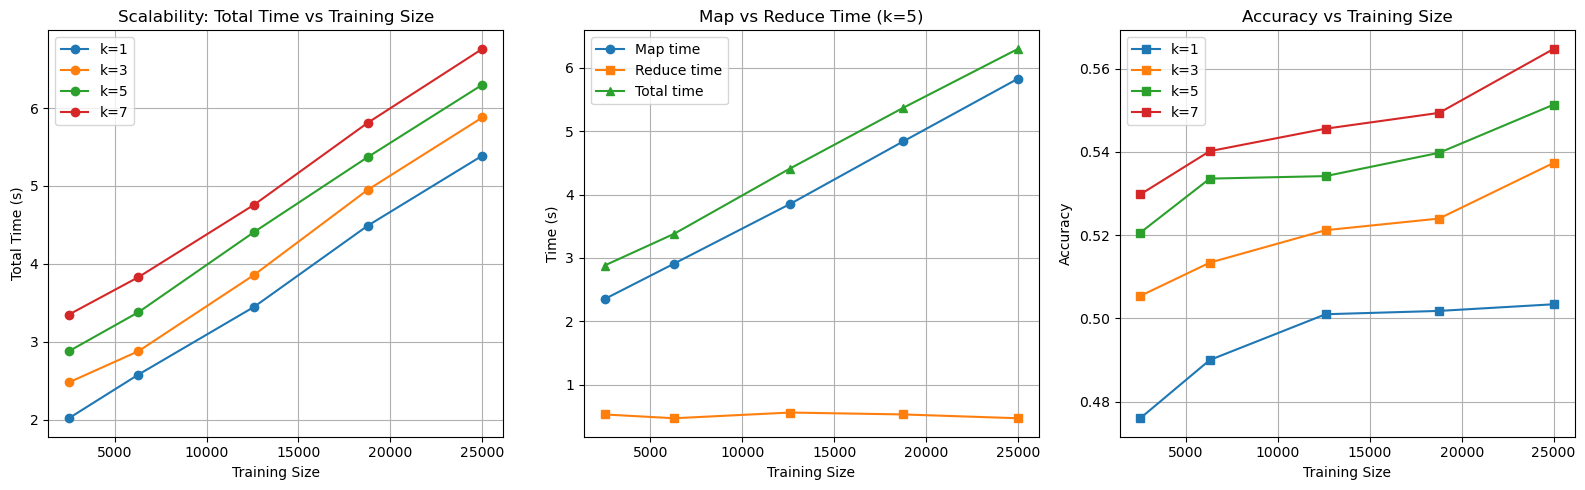

In [11]:
# Plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Total time vs training size for each k
for k_val in K_VALUES:
    subset = exp1_df[exp1_df["k"] == k_val]
    axes[0].plot(subset["n_train"], subset["TotalTime(s)"],
                 marker='o', label=f"k={k_val}")
axes[0].set_xlabel("Training Size")
axes[0].set_ylabel("Total Time (s)")
axes[0].set_title("Scalability: Total Time vs Training Size")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Map vs Reduce time breakdown (k=5)
k5 = exp1_df[exp1_df["k"] == 5]
axes[1].plot(k5["n_train"], k5["MapTime(s)"],   marker='o', label="Map time")
axes[1].plot(k5["n_train"], k5["RedTime(s)"],   marker='s', label="Reduce time")
axes[1].plot(k5["n_train"], k5["TotalTime(s)"], marker='^', label="Total time")
axes[1].set_xlabel("Training Size")
axes[1].set_ylabel("Time (s)")
axes[1].set_title("Map vs Reduce Time (k=5)")
axes[1].legend()
axes[1].grid(True)

# Plot 3: Accuracy vs training size for each k
for k_val in K_VALUES:
    subset = exp1_df[exp1_df["k"] == k_val]
    axes[2].plot(subset["n_train"], subset["Accuracy"],
                 marker='s', label=f"k={k_val}")
axes[2].set_xlabel("Training Size")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Accuracy vs Training Size")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig("k_frac_results.png", dpi=150)
plt.show()

### Varying k and # maps, using all training points

In [12]:

FRACTION2 = 1.0
N_PARTS = [256, 128, 64, 32, 16]
K_VALUES   = [1, 3, 5, 7]
records    = []
total_runs = len(N_PARTS) * len(K_VALUES)
run        = 0

for k_val in K_VALUES:
    for m in N_PARTS:
        run += 1
        train_sample = train_full.sample(False, FRACTION2, seed=42)
        print(f"[{run}/{total_runs}] k={k_val} | # Maps={m}")

        results, t_map, t_red = mr_knn_dataframe(
            train_df       = train_sample,
            test_collected = test_collected,
            test_matrix    = test_matrix,
            feature_cols   = FEATURE_COLS,
            k              = k_val,
            n_partitions   = m
        )

        acc = sum(1 for (_, p, a) in results if p == a) / len(results)
        records.append({
            "k"           : k_val,
            "# maps"      : m,
            "MapTime(s)"  : round(t_map, 2),
            "RedTime(s)"  : round(t_red, 2),
            "TotalTime(s)": round(t_map + t_red, 2),
            "Accuracy"    : round(acc, 4)
        })
        print(f"  → MapT={t_map:.2f}s | RedT={t_red:.2f}s | Acc={acc:.4f}")

exp2_df = pd.DataFrame(records)
print(exp2_df.to_string(index=False))

# Save results
exp2_df.to_csv("k_m_results.csv", index=False)
print("\nSaved to k_m_results.csv")

[1/20] k=1 | # Maps=256


/users/eleves-a/2022/kenza.chaabouni/.local/lib/python3.13/site-packages/pyspark/sql/pandas/group_ops.py:295: UserWarning: Cannot infer the eval type from type hints: functools.partial(<function map_partition at 0x7fb9d4d891c0>, test_mat=array([[ 1,  1,  1, ...,  3,  1, 12],
       [ 3, 12,  3, ...,  5,  2,  5],
       [ 1,  9,  4, ...,  2,  3,  9],
       ...,
       [ 4, 12,  1, ...,  7,  4,  6],
       [ 4,  8,  3, ..., 12,  3,  4],
       [ 1,  7,  4, ...,  2,  3,  3]], shape=(5000, 10)), feature_cols=['S1', 'C1', 'S2', 'C2', 'S3', 'C3', 'S4', 'C4', 'S5', 'C5'], k=1) is not a module, class, method, or function.
  warnings.warn(f"Cannot infer the eval type from type hints: {e}", UserWarning)


  → MapT=20.61s | RedT=3.40s | Acc=0.5082
[2/20] k=1 | # Maps=128


  → MapT=13.38s | RedT=1.91s | Acc=0.5104
[3/20] k=1 | # Maps=64


  → MapT=8.33s | RedT=0.92s | Acc=0.5110
[4/20] k=1 | # Maps=32


...

  → MapT=35.82s | RedT=11.53s | Acc=0.5660
[17/20] k=7 | # Maps=128


  → MapT=20.98s | RedT=5.85s | Acc=0.5648
[18/20] k=7 | # Maps=64


  → MapT=12.12s | RedT=3.15s | Acc=0.5714
[19/20] k=7 | # Maps=32


  → MapT=8.10s | RedT=1.36s | Acc=0.5658
[20/20] k=7 | # Maps=16


  → MapT=6.12s | RedT=0.64s | Acc=0.5648
 k  # maps  MapTime(s)  RedTime(s)  TotalTime(s)  Accuracy
 1     256       20.61        3.40         24.01    0.5082
 1     128       13.38        1.91         15.29    0.5104
 1      64        8.33        0.92          9.24    0.5110
 1      32        6.14        0.50          6.64    0.5066
 1      16        5.09        0.28          5.38    0.5034
 3     256       25.55        5.59         31.15    0.5288
 3     128       16.15        2.79         18.94    0.5330
 3      64        9.76        1.51         11.26    0.5346
 3      32        6.83        0.76          7.59    0.5276
 3      16        5.50        0.38          5.88    0.5374
 5     256       31.06        8.39         39.45    0.5508
 5     128       18.73        4.37         23.10    0.5524
 5      64       11.00        2.31         13.30    0.5554
 5      32        7.51        1.16          8.66    0.5536
 5      16        5.76        0.55          6.31    0.5514
 7     256     

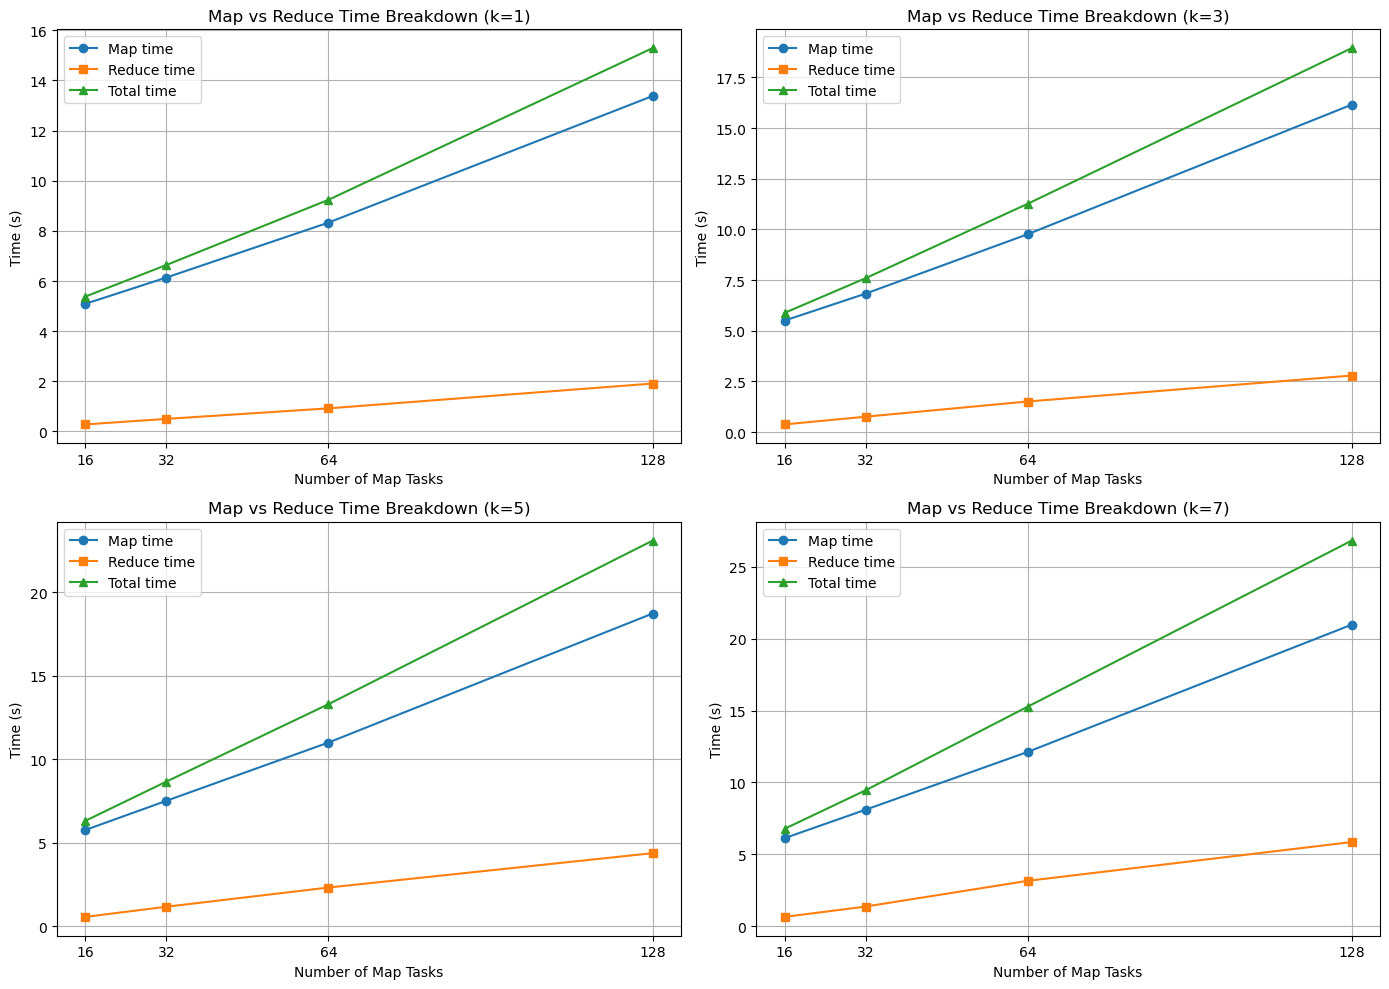

In [13]:
# Map and Reduce time breakdown vs # mappers
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, k_val in enumerate(K_VALUES):
    subset = exp2_df[exp2_df["k"] == k_val][1:]
    ax     = axes[idx]

    ax.plot(subset["# maps"], subset["MapTime(s)"],   marker='o', label="Map time")
    ax.plot(subset["# maps"], subset["RedTime(s)"],   marker='s', label="Reduce time")
    ax.plot(subset["# maps"], subset["TotalTime(s)"], marker='^', label="Total time")

    ax.set_xlabel("Number of Map Tasks")
    ax.set_ylabel("Time (s)")
    ax.set_title(f"Map vs Reduce Time Breakdown (k={k_val})")

    ax.set_xticks(subset["# maps"])
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("mrknn_time_breakdown.png", dpi=150, bbox_inches='tight')
plt.show()